In [ ]:
# change pathway only on cell 3 and run the rest
# run cell 7 if only need per-subject plots 

In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

print('Imports OK')

Imports OK


In [2]:
# ── Cell 2: Paths + subjects ──────────────────────────────────────────────────
_BASE = (
    '/Users/farjam/Library/CloudStorage'
    '/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP'
)
ECOC_ROOT  = Path(_BASE) / 'ECOC'
PLOTS_ROOT = Path(_BASE) / 'Plots'
PLOTS_ROOT.mkdir(parents=True, exist_ok=True)

AGE_DATA = {
    '1001': 25.0, '1002': 43.0, '1004': 33.0, '1005': 50.0, '1007': 31.0,
    '1008': 25.0, '1010': 26.0, '1011': 37.0, '1014': 23.0, '1016': 36.0,
    '1017': 46.0, '1018': 25.0, '1020': 29.0, '1021': 28.0, '1023': 46.0,
    '1024': 24.0, '1026': 25.0, '1028': 62.0, '1034': 60.0, '1038': 45.0,
    '1039': 63.0, '1041': 49.0, '1042': 39.0, '1044': 62.0, '1046': 61.0,
    '1052': 53.0, '2002': 62.0, '2006': 25.0, '2009': 49.0, '2017': 31.0,
    '2020': 43.0, '2023': 49.0, '2026': 47.0, '2028': 29.0, '2029': 50.0,
    '2037': 45.0, '3001': 54.0, '3005': 39.0, '3006': 33.0, '3007': 41.0,
    '3008': 32.0, '3011': 31.0, '3014': 34.0, '3016': 44.0, '3027': 72.0,
    '3030': 54.0, '3034': 48.0, '3039': 34.0, '3041': 35.0,
}
SUBJECTS = list(AGE_DATA.keys())

PATHWAYS = {
    'Luminance': {
        'contrasts': np.array([0.035, 0.07,  0.14,  0.28],  float),
        'color':     '#555555',
    },
    'L-M': {
        'contrasts': np.array([0.008, 0.016, 0.032, 0.064], float),
        'color':     '#b23333',
    },
    'S-cone': {
        'contrasts': np.array([0.06,  0.12,  0.24,  0.48],  float),
        'color':     '#3333cc',
    },
}

TIME_RANGE = [0.05, 0.30]   # seconds — analysis window for peak detection

print(f'Subjects : {len(SUBJECTS)}')
print(f'Plots    : {PLOTS_ROOT}')

Subjects : 49
Plots    : /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots


In [15]:
# ── Cell 3: Pathway choice ────────────────────────────────────────────────────
# Change PATHWAY here, then re-run this cell before running Cells 5, 7, 8.
# Cell 6 loops all pathways automatically — no change needed there.

PATHWAY = 'S-cone'   # ← 'Luminance', 'L-M', or 'S-cone'

ecoc_dir  = ECOC_ROOT  / PATHWAY
plots_dir = PLOTS_ROOT / PATHWAY
plots_dir.mkdir(parents=True, exist_ok=True)

contrasts = PATHWAYS[PATHWAY]['contrasts']
color     = PATHWAYS[PATHWAY]['color']
n_levels  = len(contrasts)
chance    = 1.0 / n_levels

print(f'Pathway  : {PATHWAY}')
print(f'ECOC dir : {ecoc_dir}')
print(f'Plots dir: {plots_dir}')

Pathway  : S-cone
ECOC dir : /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/ECOC/S-cone
Plots dir: /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/S-cone


In [16]:
# ── Cell 4: Helper functions ──────────────────────────────────────────────────
# Run once after Cell 2. No computation happens here.

def load_accuracies(pathway):
    """Load accuracy curves for all subjects → (times, acc_matrix [n_subj, n_win])."""
    d = ECOC_ROOT / pathway
    times, accs = None, []
    for subject in SUBJECTS:
        f = d / f'sub-{subject}_ecoc_results.npz'
        if not f.exists():
            continue
        with np.load(f, allow_pickle=False) as data:
            t = data['time_decoder'].ravel()
            a = data['accuracies'].ravel()
        if times is None:
            times = t
        accs.append(a)
    return times, np.vstack(accs)


def group_peak(pathway):
    """Return (group_peak_time, group_peak_index, times) for a pathway."""
    times, A = load_accuracies(pathway)
    m   = np.nanmean(A, 0)
    inr = (times >= TIME_RANGE[0]) & (times <= TIME_RANGE[1])
    if np.any(inr):
        idx = int(np.where(inr)[0][np.argmax(m[inr])])
    else:
        idx = int(np.argmax(m))
    return float(times[idx]), idx, times


def subject_peak(t, acc):
    """Index of a single subject's peak accuracy within TIME_RANGE."""
    inr = (t >= TIME_RANGE[0]) & (t <= TIME_RANGE[1])
    if np.any(inr):
        return int(np.where(inr)[0][np.argmax(acc[inr])])
    return int(np.argmax(acc))


def cm_to_rdm(cm):
    """Row-normalised confusion matrix → d-prime RDM."""
    cm = cm / (cm.sum(axis=1, keepdims=True) + 1e-9)
    S  = 0.5 * (cm + cm.T)
    A  = 1.0 - S
    np.fill_diagonal(A, 0.5)
    A  = 0.5 * (A + A.T)
    np.fill_diagonal(A, 0.5)
    eps = 1e-6
    p   = np.clip(A, 0.5 + eps, 1 - eps)
    D   = np.sqrt(2) * norm.ppf(p)
    D  -= D.min()
    D   = 0.5 * (D + D.T)
    np.fill_diagonal(D, 0.0)
    return D


def heatmap(M, title, ax, cmap, vmin=None, vmax=None, labels=None):
    """Annotated heatmap on a given Axes."""
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax,
                   origin='upper', aspect='equal')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if labels is not None:
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=8)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            bright = (vmin is not None and vmax is not None
                      and (v - vmin) / max(vmax - vmin, 1e-9) > 0.5)
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if bright else 'black')
    ax.grid(False)


print('Helpers OK')

Helpers OK


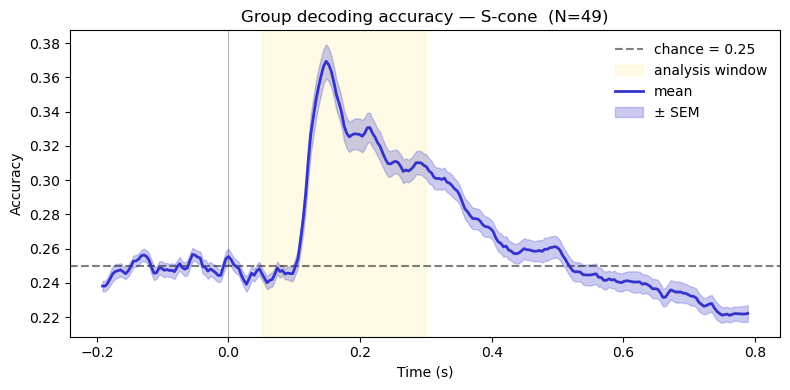

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/S-cone/S-cone_group_accuracy.png


In [17]:
# ── Cell 5: Group decoding accuracy — one pathway ─────────────────────────────
# Uses PATHWAY set in Cell 3.

times, A = load_accuracies(PATHWAY)
m   = np.nanmean(A, 0)
sem = np.nanstd(A, 0, ddof=1) / np.sqrt(A.shape[0])

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_title(f'Group decoding accuracy — {PATHWAY}  (N={A.shape[0]})')
ax.axhline(chance, ls='--', color='k', alpha=0.5, label=f'chance = {chance:.2f}')
ax.axvline(0, color='k', lw=0.8, alpha=0.3)
ax.axvspan(*TIME_RANGE, color='gold', alpha=0.10, label='analysis window')
ax.plot(times, m, color=color, lw=2, label='mean')
ax.fill_between(times, m - sem, m + sem, color=color, alpha=0.25, label='± SEM')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Accuracy')
ax.legend(frameon=False)
fig.tight_layout()

out = plots_dir / f'{PATHWAY}_group_accuracy.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

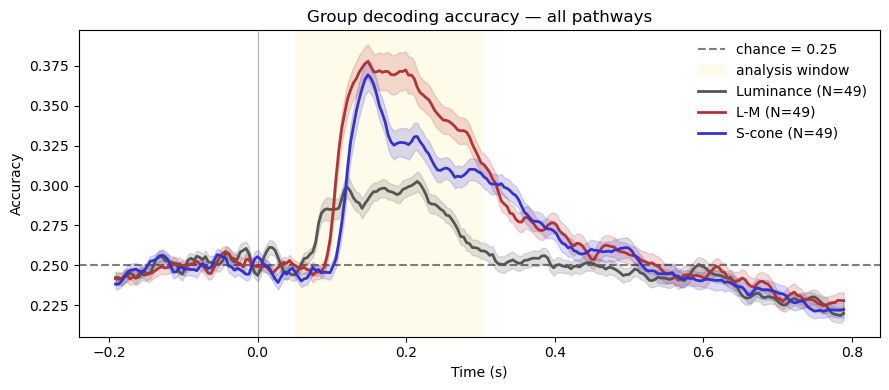

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/all_pathways_group_accuracy.png


In [18]:
# ── Cell 6: All three pathways on one accuracy plot ───────────────────────────
# No pathway change needed — loops all three automatically.

fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title('Group decoding accuracy — all pathways')
ax.axhline(0.25, ls='--', color='k', alpha=0.5, label='chance = 0.25')
ax.axvline(0, color='k', lw=0.8, alpha=0.3)
ax.axvspan(*TIME_RANGE, color='gold', alpha=0.08, label='analysis window')

for pw, info in PATHWAYS.items():
    times, A = load_accuracies(pw)
    m   = np.nanmean(A, 0)
    sem = np.nanstd(A, 0, ddof=1) / np.sqrt(A.shape[0])
    c   = info['color']
    ax.plot(times, m, color=c, lw=2, label=f'{pw} (N={A.shape[0]})')
    ax.fill_between(times, m - sem, m + sem, color=c, alpha=0.18)

ax.set_xlabel('Time (s)'); ax.set_ylabel('Accuracy')
ax.legend(frameon=False)
fig.tight_layout()

out = PLOTS_ROOT / 'all_pathways_group_accuracy.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

In [ ]:
# ── Cell 7: Per-subject CM + RDM — both time points ──────────────────────────
#
# For each subject saves TWO figures:
#   sub-<ID>_cm_rdm_own_peak.png   — CM at subject's own peak window
#   sub-<ID>_cm_rdm_group_peak.png — CM at the group peak window
#
# Uses PATHWAY set in Cell 3.

labs = [f'{c:g}' for c in contrasts]

# Compute group peak index once for this pathway
gtime, gidx, gtimes = group_peak(PATHWAY)
print(f'Group peak ({PATHWAY}): {gtime:.3f} s')

for subject in SUBJECTS:
    f = ecoc_dir / f'sub-{subject}_ecoc_results.npz'
    if not f.exists():
        print(f'[{subject}] missing — skip'); continue

    with np.load(f, allow_pickle=False) as d:
        t   = d['time_decoder'].ravel()
        acc = d['accuracies'].ravel()
        cms = d['confusion_matrices']

    sidx = subject_peak(t, acc)   # this subject's own peak

    for label, widx in [('own_peak', sidx), ('group_peak', gidx)]:
        cm   = cms[widx]
        Ssym = 0.5 * (cm + cm.T)
        D    = cm_to_rdm(cm)

        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        fig.suptitle(
            f'sub-{subject}  |  {PATHWAY}  |  t = {t[widx]:.3f} s  ({label.replace("_", " ")})',
            fontsize=10
        )
        heatmap(cm,   'Confusion matrix',    axes[0], 'Blues', 0, 1,    labs)
        heatmap(Ssym, 'Symmetric confusion', axes[1], 'PuBu',  0, 1,    labs)
        heatmap(D,    'RDM  (d\u2032)',      axes[2], 'magma', 0, None, labs)
        fig.tight_layout()

        out = plots_dir / f'sub-{subject}_cm_rdm_{label}.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        plt.close(fig)

    print(f'[{subject}] saved (own peak @ {t[sidx]:.3f}s | group peak @ {gtime:.3f}s)')

Group peak (S-cone): 0.148 s


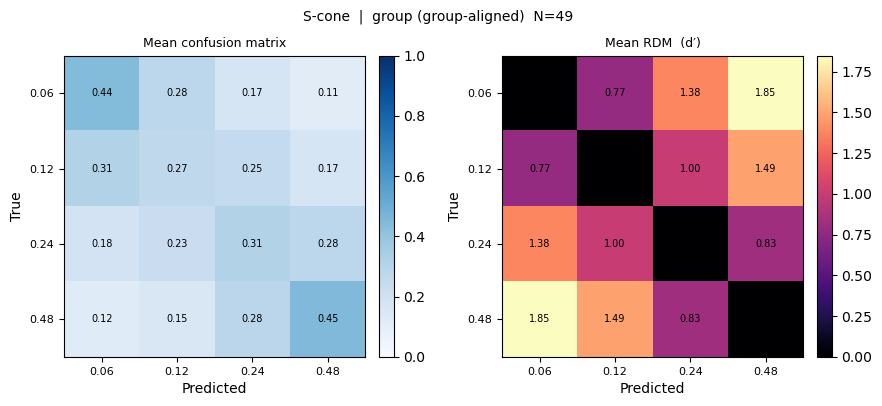

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/S-cone/S-cone_group_cm_rdm_group.png


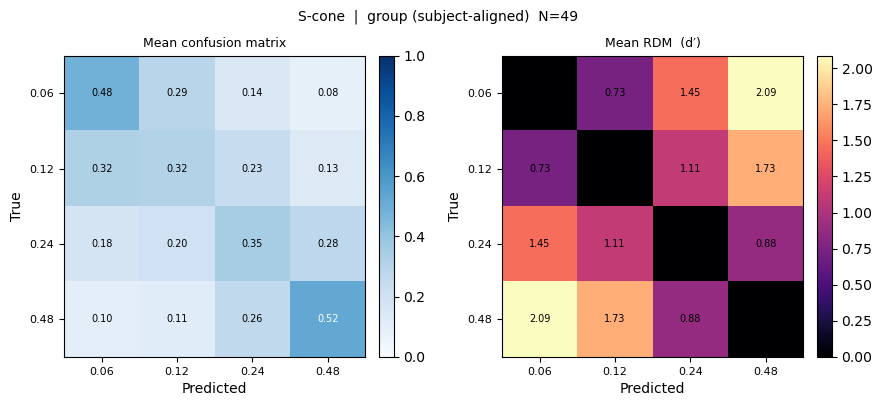

Saved → /Users/farjam/Library/CloudStorage/OneDrive-UniversityofEdinburgh/wellcome/Amir/Final_VEP/Plots/S-cone/S-cone_group_cm_rdm_subject.png


In [19]:
# ── Cell 8: Group CM + RDM — both alignments ─────────────────────────────────
#
# Saves TWO figures automatically:
#   <pathway>_group_cm_rdm_group.png   — all subjects at group peak time
#   <pathway>_group_cm_rdm_subject.png — each subject at their own peak, then averaged
#
# Uses PATHWAY set in Cell 3.

labs = [f'{c:g}' for c in contrasts]

# Group peak index (computed once)
gtime, gidx, gtimes = group_peak(PATHWAY)
print(f'Group peak ({PATHWAY}): {gtime:.3f} s')

for align in ['group', 'subject']:

    CMs, Ds = [], []
    for subject in SUBJECTS:
        f = ecoc_dir / f'sub-{subject}_ecoc_results.npz'
        if not f.exists():
            continue
        with np.load(f, allow_pickle=False) as d:
            t   = d['time_decoder'].ravel()
            acc = d['accuracies'].ravel()
            cms = d['confusion_matrices']

        widx = gidx if align == 'group' else subject_peak(t, acc)
        cm   = cms[widx]
        CMs.append(cm)
        Ds.append(cm_to_rdm(cm))

    CM_mean = np.nanmean(np.stack(CMs), 0)
    D_mean  = np.nanmean(np.stack(Ds),  0)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    fig.suptitle(
        f'{PATHWAY}  |  group ({align}-aligned)  N={len(CMs)}',
        fontsize=10
    )
    heatmap(CM_mean, 'Mean confusion matrix', axes[0], 'Blues', 0, 1,    labs)
    heatmap(D_mean,  'Mean RDM  (d\u2032)',   axes[1], 'magma', 0, None, labs)
    fig.tight_layout()

    out = plots_dir / f'{PATHWAY}_group_cm_rdm_{align}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out}')